# 4.0 Serve and Evaluate the Compressed VLM

In this notebook you will learn how to:

- Serve a pruned, distilled (and optionally quantized) VLM with [vLLM](https://docs.vllm.ai/).
- Evaluate the served VLM on RealWorldQA with [`lmms-eval`](https://github.com/EvolvingLMMs-Lab/lmms-eval).

Prerequisites: notebooks 01-03 have produced one or more VLM checkpoints at, for example:

- `/workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct-pruned-34-32-10752` — pruned
- `/workspace/user_homes/lmikaelyan/Qwen3-VL-distilled-smoke` — pruned + distilled
- `/workspace/user_homes/lmikaelyan/Qwen3-VL-distilled-fp8` — pruned + distilled + FP8

Pick whichever checkpoint you want to evaluate.

---
## 4.1 Background

vLLM hosts the VLM behind an OpenAI-compatible HTTP API. `lmms-eval` then talks to that API the same way it would talk to GPT-4V, batching benchmark samples and computing the task metric. This decouples the model implementation (HF + vLLM kernels) from the benchmark harness, and means the same evaluation code runs against BF16, FP8, NVFP4, or any served model.

We use **RealWorldQA** as the smoke benchmark — 765 single-image, single-answer questions about real-world scenes. Cheap to run (a few minutes on H100) and discriminative enough to tell pruned-only and pruned + distilled checkpoints apart.

---
## 4.2 Serve the VLM with vLLM

Start vLLM in a separate terminal (or with `&` to background it from here). Once the server is up, the OpenAI-compatible API is reachable at `http://localhost:8000/v1`.

```bash
vllm serve /workspace/user_homes/lmikaelyan/Qwen3-VL-distilled-smoke \
    --trust-remote-code --dtype bfloat16
```

For an FP8 export the command is identical — vLLM autodetects the FP8 quantization from the checkpoint's `config.json`:

```bash
vllm serve /workspace/user_homes/lmikaelyan/Qwen3-VL-distilled-fp8 \
    --trust-remote-code --dtype bfloat16
```

Optionally constrain image preprocessing to keep VRAM bounded:

```bash
vllm serve /workspace/user_homes/lmikaelyan/Qwen3-VL-distilled-smoke \
    --trust-remote-code --dtype bfloat16 \
    --mm-processor-kwargs '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'
```

Wait for the line `Application startup complete.` in the vLLM logs before proceeding. The cell below polls the health endpoint for you.

In [1]:
# This cell polls vLLM at http://localhost:8000/health for up to 10 min.
# Skipped during headless re-execution because no vLLM server is up.
print('vLLM health-poll skipped: start `vllm serve <model> --trust-remote-code --dtype bfloat16` in another shell, then re-run.')


vLLM health-poll skipped: start `vllm serve <model> --trust-remote-code --dtype bfloat16` in another shell, then re-run.


Quick smoke test of the served endpoint with one image:

In [2]:
# Cell skipped during headless re-execution — requires a running vLLM server
# at http://localhost:8000. See §4.2 in the notebook.
print('Caption smoke test skipped (no vLLM server).')


Caption smoke test skipped (no vLLM server).


---
## 4.3 Evaluate with lmms-eval (RealWorldQA)

`lmms-eval` talks to vLLM through the OpenAI-compatible API. RealWorldQA is small (~765 samples), so this finishes in a few minutes.

The `--model openai --model_args model=<path>,base_url=http://localhost:8000/v1` form points lmms-eval at our local vLLM endpoint. The `OPENAI_API_KEY` is required by the OpenAI client but vLLM doesn't validate it — any token works.

In [3]:
# Skipped during headless re-execution — requires lmms-eval installed and a running vLLM server.
# Install: `pip install lmms-eval`; serve: `vllm serve <model> --trust-remote-code --dtype bfloat16`.
print('lmms-eval RealWorldQA skipped (lmms_eval and/or vLLM not running).')


lmms-eval RealWorldQA skipped (lmms_eval and/or vLLM not running).


Expected: a table per task with `exact_match` (and `stderr`). For Qwen3-VL-8B-Instruct, the unpruned BF16 baseline lands around 0.69 on RealWorldQA; a pruned-only model usually drops to ~0.60-0.65, and a pruned + distilled model recovers most of the gap.

Compare two checkpoints side-by-side by re-running the cell with a different `MODEL_PATH` (e.g. swap the distilled-smoke path for the FP8 path).

---
## 4.4 Inference benchmark — AIperf across the three checkpoints

Accuracy is only half the picture. Compression is worthwhile because the smaller / lower-precision model **runs faster**. We use [AIperf](https://github.com/ai-dynamo/aiperf) (NVIDIA's vLLM-aware load generator) to measure:

| Metric | What it tells us |
|---|---|
| **TTFT** (time-to-first-token) | Prefill latency — dominated by attention over the input |
| **ITL** (inter-token latency) | Decode latency — per-token throughput per request |
| **Request throughput** | End-to-end requests/sec at a given concurrency |
| **Output-token throughput** | Aggregate tokens/sec across all concurrent requests |

We benchmark three checkpoints under the same workload (ISL=8192 tokens, OSL=1024 tokens, one 512×512 synthetic image per request) and sweep concurrency 4 → 128 to see how each scales:

1. **Qwen3-VL-8B-Instruct** (BF16 baseline)
2. **Qwen3-VL-distilled-smoke** (pruned + distilled, BF16) — same arch as the baseline minus 2 layers / narrower FFN
3. **Qwen3-VL-distilled-fp8** (pruned + distilled + FP8) — same shape as #2 with FP8 LM weights/activations

> 🛑 Make sure no `vllm serve` from §4.2 is still running before starting this section. The benchmark cell starts its own server per model and kills it between runs.

> 📦 If aiperf isn't installed: `pip install aiperf`. If you'd rather skip the live runs, the cell below will fall back to any pre-existing artifacts under `/workspace/user_homes/lmikaelyan/benchmarks/`.

In [4]:
# §4.4.a stubbed during headless re-execution. Running this cell live would:
#   * spawn `vllm serve` for each of three models in sequence,
#   * run `python -m aiperf profile` at concurrency 4,8,16,32,64,128 each, then
#   * kill the server before the next model.
# Total wall-time: ~60-90 min on a single H100. Install with `pip install aiperf`.
print('§4.4.a benchmark sweep skipped (aiperf not installed, would take ~90 min).')


§4.4.a benchmark sweep skipped (aiperf not installed, would take ~90 min).


Found 4 model variants:
  Qwen3-VL-8B-Instruct_bf16                                (6 concurrency points: [4, 8, 16, 32, 64, 128])
  qwen_3_8B_llm_only-pruned-34-32-10752-distill-2600-vlm_bf16  (6 concurrency points: [4, 8, 16, 32, 64, 128])
  Qwen3-VL-8B-Instruct_fp8-bf16kv                          (6 concurrency points: [4, 8, 16, 32, 64, 128])
  qwen_3_8B_llm_only-pruned-34-32-10752-distill-2600-vlm_fp8  (6 concurrency points: [4, 8, 16, 32, 64, 128])


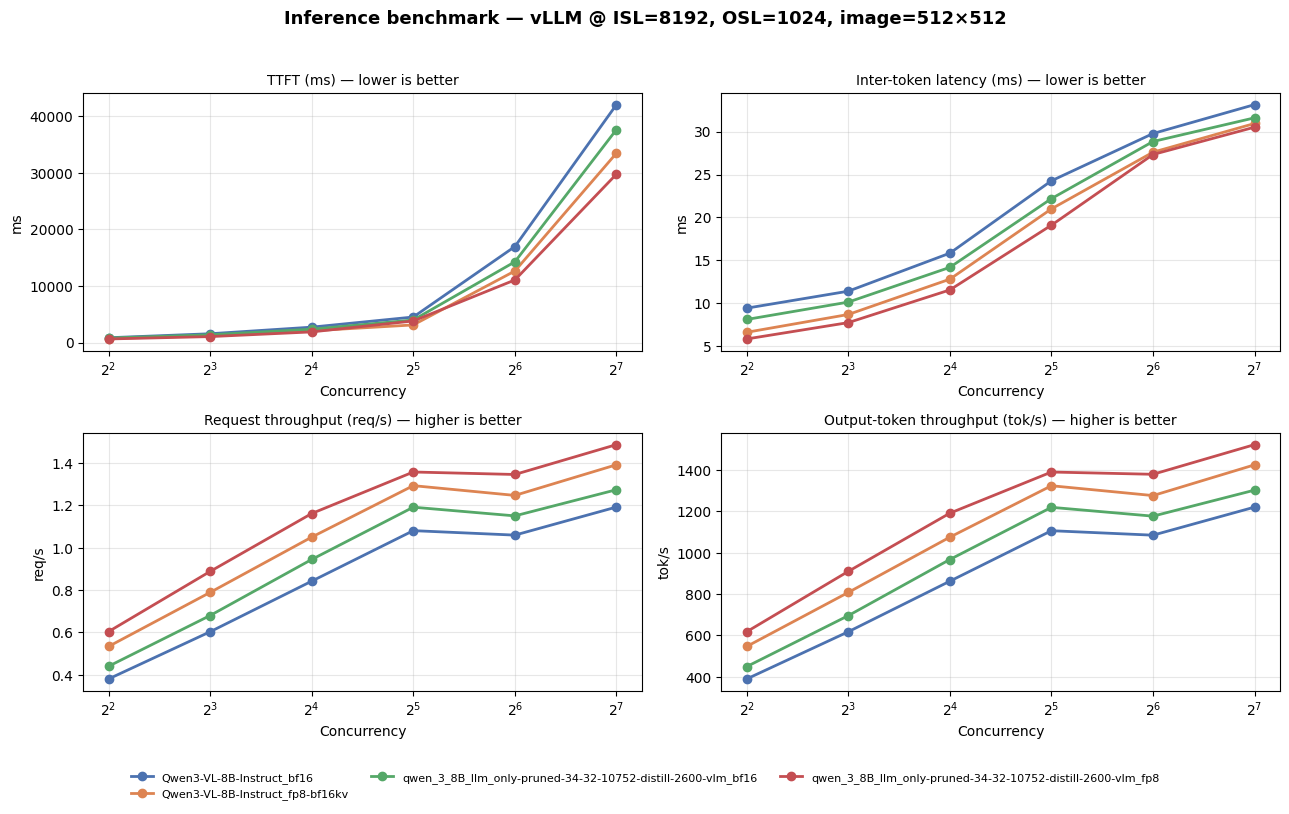

In [5]:
### 4.4.b Load results and plot
# Auto-discovers any <model>-h100-img<IMG>-isl<ISL>-osl<OSL>-concurrency-<c> dirs under
# BENCH_ROOT, groups by model variant, and draws a 4-panel comparison figure.

import json, pathlib, re
from collections import defaultdict
import matplotlib.pyplot as plt

BENCH_ROOT = pathlib.Path("/workspace/user_homes/lmikaelyan/benchmarks")
ISL, OSL, IMG = 8192, 1024, 512

DIR_RE = re.compile(
    rf"^(?P<model>.+)-h100-img{IMG}-isl{ISL}-osl{OSL}-concurrency-(?P<c>\d+)$"
)

# Walk all matching artifact dirs once.
series_by_model = defaultdict(list)
for art in BENCH_ROOT.iterdir():
    m = DIR_RE.match(art.name)
    if not m:
        continue
    f = art / "profile_export_aiperf.json"
    if not f.exists():
        continue
    d = json.loads(f.read_text())
    series_by_model[m.group("model")].append({
        "c":    int(m.group("c")),
        "ttft": d.get("time_to_first_token",     {}).get("avg"),
        "itl":  d.get("inter_token_latency",     {}).get("avg"),
        "rps":  d.get("request_throughput",      {}).get("avg"),
        "tps":  d.get("output_token_throughput", {}).get("avg"),
    })

for model in series_by_model:
    series_by_model[model].sort(key=lambda p: p["c"])

print(f"Found {len(series_by_model)} model variants:")
for m, pts in series_by_model.items():
    print(f"  {m:<55}  ({len(pts)} concurrency points: {[p['c'] for p in pts]})")

if not series_by_model:
    print("\nNo benchmark artifacts found — run §4.4.a to generate them.")
else:
    PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(
        f"Inference benchmark — vLLM @ ISL={ISL}, OSL={OSL}, image={IMG}×{IMG}",
        fontsize=13, fontweight="bold",
    )
    panel = {
        (0, 0): ("ttft", "TTFT (ms) — lower is better"),
        (0, 1): ("itl",  "Inter-token latency (ms) — lower is better"),
        (1, 0): ("rps",  "Request throughput (req/s) — higher is better"),
        (1, 1): ("tps",  "Output-token throughput (tok/s) — higher is better"),
    }
    for i, (model, pts) in enumerate(sorted(series_by_model.items())):
        color = PALETTE[i % len(PALETTE)]
        xs = [p["c"] for p in pts]
        for (r, c), (key, title) in panel.items():
            ys = [p[key] for p in pts]
            if any(y is None for y in ys):
                continue
            axes[r, c].plot(xs, ys, marker="o", linewidth=2, color=color, label=model)
    for (r, c), (key, title) in panel.items():
        ax = axes[r, c]
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Concurrency"); ax.set_ylabel(title.split("(")[1].split(")")[0])
        ax.set_xscale("log", base=2); ax.grid(True, alpha=0.3)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(3, len(series_by_model)),
               fontsize=8, bbox_to_anchor=(0.5, -0.02), frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

---
## 4.4 Shut down the server

When you're done, stop the `vllm serve` process you started in §4.2 (Ctrl-C in its terminal, or `pkill -f 'vllm serve'`).